# Backpropagation and Neural Networks

Backpropagation, short for "backward propagation of errors," is the key algorithm that powers the training of artificial neural networks. It is a way of enabling deep networks to learn complex patterns in data through more efficient weight updates. 

The core idea behind backpropagation is to compute how much each network parameter (such as a weight or bias) contributes to the prediction error and to then adjust these parameters to minimize the overall error. This process relies on the chain rule of calculus to propagate the error backwards through the network, starting from the output layer and moving towards the input layer.

Backpropagation works by iteratively updating weights using gradient descent. The algorithm involves two key phases: **the forward pass**, where the input data is passed through the network to generate predictions, and **the backward pass**, where the error is calculated and gradients are computed to update the weights. By iteratively reducing the error with each epoch, the network "learns" the optimal parameters.

![](https://miro.medium.com/v2/resize:fit:1080/0*d9yJ5xIqdbDyjCYR.gif)

## Backpropogation and The Chain Rule

A key mathematical concept underlying backpropagation is the **chain rule**, which is used to compute derivatives of composite functions. Since a neural network is essentially a nested composition of functions, where each layer applies an activation function to a linear combination of inputs, the chain rule enables us to compute how changes in a given parameter (like a weight or bias) affect the final network output.

The chain rule states that if we have a composite function $f(x) = g(h(x))$, then the derivative of $f$ with respect to $x$ is given by:  
$$
\frac{df}{dx} = \frac{dg}{dh} \cdot \frac{dh}{dx}
$$  

In the context of backpropagation, this means that we can compute the gradient of the overall loss $L$ with respect to the weights $w$ by sequentially propagating gradients backward through the network. For example, if $L$ depends on the output of layer $k$ and layer $k$ depends on layer $k-1$, the chain rule tells us that:  

$$
\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a_k} \cdot \frac{\partial a_k}{\partial z_k} \cdot \frac{\partial z_k}{\partial w}
$$  

where:
- $a_k$ is the activation of the layer,
- $z_k$ is the linear combination of inputs to that layer, and
- $w$ represents the weights connecting to the layer.

By applying the chain rule iteratively from the output layer back to the input layer, backpropagation efficiently computes the gradients needed to update all the parameters in the network. This is the key to optimizing deep networks through gradient descent.


## Simple Backpropogation Example

Let’s consider a simple neural network with:
- 1 input layer (2 features),
- 1 hidden layer (2 neurons), and
- 1 output neuron.

We will manually walk through the **forward pass** and **backpropagation** using the following data:

**Inputs:**  
$$
X = \begin{bmatrix} 0.5 \\ 0.2 \end{bmatrix}
$$

**True output:** $ y = 1 $

**Weights and biases:**  
$$
W_1 = \begin{bmatrix} 0.4 & 0.1 \\ 0.3 & 0.7 \end{bmatrix}, \quad b_1 = \begin{bmatrix} 0.1 \\ 0.2 \end{bmatrix}
$$  

$$
W_2 = \begin{bmatrix} 0.5 & 0.6 \end{bmatrix}, \quad b_2 = 0.3
$$

### The Forward Pass

In a neural network, the **forward pass** is the process of passing the input data through the network to produce an output. The input is propagated layer by layer through **linear transformations** and **non-linear activation functions** until a final prediction is obtained.

At each layer $ l $, the input is transformed using the following steps:

1. **Linear Transformation:**  
    The inputs are multiplied by weights and added to biases:  
    $$
    z^{(l)} = W^{(l)} \cdot a^{(l-1)} + b^{(l)}
    $$  
    
    where:  
    - $ z^{(l)} $ is the pre-activation value of layer $ l $,  
    - $ W^{(l)} $ is the weight matrix for layer $ l $,  
    - $ a^{(l-1)} $ is the activation from the previous layer, and  
    - $ b^{(l)} $ is the bias vector for layer $ l $.

2. **Activation Function:**  
    A non-linear activation function is applied to the pre-activation $ z^{(l)} $ to get the activation of the current layer:  
    $$
    a^{(l)} = \sigma(z^{(l)})
    $$  
    
    Common activation functions include sigmoid, ReLU, and tanh.


In [4]:
import numpy as np

# Define the sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Input data (2 features, 1 sample)
X = np.array([[0.5], [0.2]])

# Initialize weights and biases for a 2-layer neural network
W1 = np.array([[0.4, 0.1], [0.3, 0.7]])  # Weights for the hidden layer
b1 = np.array([[0.1], [0.2]])            # Biases for the hidden layer

W2 = np.array([[0.5, 0.6]])              # Weights for the output layer
b2 = np.array([[0.3]])                   # Bias for the output layer

# Forward pass
z1 = np.dot(W1, X) + b1  # Linear transformation for the hidden layer
a1 = sigmoid(z1)         # Activation for the hidden layer

z2 = np.dot(W2, a1) + b2  # Linear transformation for the output layer
a2 = sigmoid(z2)          # Activation for the output layer (final prediction)

print("Output of the neural network:", a2)

Output of the neural network: [[0.72346724]]


### Backpropagation

The goal of backpropagation is to calculate the **gradient of the loss function** with respect to the network’s weights and biases, so that these parameters can be updated using gradient descent. The key to backpropagation is the **chain rule**, which allows us to propagate the error backward through the network.


1. **Compute the Loss:**  
    Assume a loss function $L$ (e.g., Mean Squared Error or Cross-Entropy Loss).
    $$
    L = \frac{1}{2} (a_2 - y)^2
    $$

2. **Compute Output Error:**  
    Compute the derivative of the loss with respect to the output activation $a^{(L)}$:

    $$
    \delta^{(L)} = \frac{\partial L}{\partial a^{(L)}} \cdot \sigma'(z^{(L)})
    $$

    Here, $\delta^{(L)}$ is the error signal at the output layer, and $\sigma'(z)$ is the derivative of the activation function.

3. **Backpropagate Error:**  
    For each previous layer $l$, propagate the error backward:

    $$
    \delta^{(l)} = \big( W^{(l+1)} \big)^T \cdot \delta^{(l+1)} \cdot \sigma'(z^{(l)})
    $$

4. **Calculate Gradients:**  
    The gradients of the loss with respect to the weights and biases are:

    $$
    \frac{\partial L}{\partial W^{(l)}} = \delta^{(l)} \cdot \big( a^{(l-1)} \big)^T \quad \text{and} \quad \frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}
    $$


In [5]:
# Define the derivative of the sigmoid function
def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

# Assume the network's output and the true label
y_true = np.array([[1]])  # True label
print("Predicted:", a2)
print("Actual:", y_true)
loss_derivative = a2 - y_true  # Derivative of the Mean Squared Error loss

# Backpropagation
delta2 = loss_derivative * sigmoid_derivative(z2)  # Output layer error
dW2 = np.dot(delta2, a1.T)  # Gradient for W2
db2 = delta2  # Gradient for b2

delta1 = np.dot(W2.T, delta2) * sigmoid_derivative(z1)  # Hidden layer error
dW1 = np.dot(delta1, X.T)  # Gradient for W1
db1 = delta1  # Gradient for b1

print("Gradients for W1:", dW1)
print("Gradients for W2:", dW2)

Predicted: [[0.72346724]]
Actual: [[1]]
Gradients for W1: [[-0.00337071 -0.00134828]
 [-0.00390986 -0.00156394]]
Gradients for W2: [[-0.03205042 -0.03430665]]


### Weight Updates
Update the weights using gradient descent, where $ \eta $ is the learning rate:  

$$
W^{(l)} = W^{(l)} - \eta \frac{\partial L}{\partial W^{(l)}}
$$  

## California Housing Dataset Regression Example

In [6]:
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

#### Prepare The Dataset

In [7]:
# Load and preprocess the California Housing dataset
housing = fetch_california_housing()
X = housing.data    # Features: median income, house age, avg rooms, etc.
y = housing.target.reshape(-1, 1)  # Median house value (in $100,000s)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Feature names: {list(housing.feature_names)}")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training set shape: (16512, 8)
Test set shape:     (4128, 8)


#### Build And Compile Neural Network

In [8]:
# Build a simple neural network using TensorFlow
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # 8 features
    tf.keras.layers.Dense(64, activation='relu'),       # Hidden layer
    tf.keras.layers.Dense(1)                            # Regression output
])

In [9]:
# Compile the model with the optimizer and loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='mean_squared_error',
              metrics=['mae'])

In [10]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_split=0.1, verbose=1)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - loss: 0.5794 - mae: 0.5130 - val_loss: 0.4355 - val_mae: 0.4661
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - loss: 0.4343 - mae: 0.4507 - val_loss: 0.4243 - val_mae: 0.4606
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - loss: 0.3722 - mae: 0.4296 - val_loss: 0.3699 - val_mae: 0.4240
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - loss: 0.3861 - mae: 0.4290 - val_loss: 0.3727 - val_mae: 0.4227
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step - loss: 0.3483 - mae: 0.4130 - val_loss: 0.3591 - val_mae: 0.4217
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 0.3435 - mae: 0.4125 - val_loss: 0.3709 - val_mae: 0.4173
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - loss: 0.3745 - mae: 0.4171 - val_loss: 0.4148 - val_mae: 0.4627
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - loss: 0.3493 - mae: 0.4141 - val_loss: 0.3738 - val_mae: 0.4204
Epoch 9/100
465/465 ━━━━━━━━━━━━

#### Evaluate The Model

In [11]:
# Evaluate the model on test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal test loss (MSE): {test_loss:.4f}")
print(f"Final test MAE: {test_mae:.4f}")


Final test loss (MSE): 0.3240
Final test MAE: 0.3967


#### Make Predictions

In [12]:
# Make predictions on new data
predictions = model.predict(X_test[:5])  # Predict on the first 5 test samples

# Display predictions and ground truth
for i in range(5):
    print(f"Sample {i + 1}: Predicted price = {predictions[i][0]:.2f}, Actual price = {y_test[i][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Sample 1: Predicted price = 0.68, Actual price = 0.48
Sample 2: Predicted price = 1.18, Actual price = 0.46
Sample 3: Predicted price = 4.78, Actual price = 5.00
Sample 4: Predicted price = 2.64, Actual price = 2.19
Sample 5: Predicted price = 2.63, Actual price = 2.78


#### What's Missing Here? 

**There is no explicit call to do backward propogation here.** Instead, TensorFlow automatically handles both the forward pass and backpropagation during training when model.fit() is called.

During the forward pass, TensorFlow propagates the input through the network, computing the output by applying the weights, biases, and activation functions at each layer. 

It then calculates the loss by comparing the predicted output to the actual target using the specified loss function (e.g., mean squared error). 

In the backward pass (backpropagation), TensorFlow computes the gradients of the loss with respect to the model parameters (weights and biases) using automatic differentiation. The optimizer (e.g., Adam) updates the parameters using these gradients to minimize the loss.

**This entire process is automated and optimized within TensorFlow using the computational graph and tf.GradientTape internally.** As a result, you don’t need to manually compute gradients or update weights as TensorFlow does these steps under the hood.

#### Same Architecture, But Manual Loop

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # 8 features
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [14]:
# Compile the model with the optimizer and loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='mean_squared_error',
              metrics=['mae'])

In [15]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()

# Manual training loop with backpropagation
epochs = 100
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        predictions = model(X_train, training=True)  # Forward pass
        loss = loss_fn(y_train, predictions)  # Compute loss
    
    # Backpropagation: compute gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # Apply gradients to update weights
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

Epoch 0, Loss: 6.474331378936768
Epoch 10, Loss: 1.2034517526626587
Epoch 20, Loss: 1.0176578760147095
Epoch 30, Loss: 0.7064183950424194
Epoch 40, Loss: 0.6316114068031311
Epoch 50, Loss: 0.5704586505889893
Epoch 60, Loss: 0.5189507007598877
Epoch 70, Loss: 0.4832971394062042
Epoch 80, Loss: 0.45666810870170593
Epoch 90, Loss: 0.4370332360267639


In [16]:
# Evaluate the model on test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal test loss (MSE): {test_loss:.4f}")
print(f"Final test MAE: {test_mae:.4f}")


Final test loss (MSE): 0.4325
Final test MAE: 0.4686


In [17]:
# Make predictions on new data
predictions = model.predict(X_test[:5])  # Predict on the first 5 test samples

# Display predictions and ground truth
for i in range(5):
    print(f"Sample {i + 1}: Predicted price = {predictions[i][0]:.2f}, Actual price = {y_test[i][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Sample 1: Predicted price = 0.40, Actual price = 0.48
Sample 2: Predicted price = 1.54, Actual price = 0.46
Sample 3: Predicted price = 3.33, Actual price = 5.00
Sample 4: Predicted price = 2.55, Actual price = 2.19
Sample 5: Predicted price = 2.70, Actual price = 2.78


## Real-World Application: Predicting Household Appliance Energy Use

The toy datasets so far are useful for learning the mechanics, but real-world deep learning problems are messier. In this section we'll work through a complete applied workflow on a genuine sensor dataset; the kind of problem you might see on a smart-home or grid-planning team.

**Business framing.** Utilities, smart-thermostat vendors (Nest, Ecobee, Sense)and building-management platforms care a lot about predicting *short-horizon appliance energy consumption*. Accurate predictions let them:
- shift loads to off-peak periods to reduce customer bills,
- flag anomalous consumption (a fridge dying, a forgotten space heater),
- help utilities forecast aggregate demand and avoid spinning up peaker plants.

**Dataset.** We'll use the
[UCI Appliances Energy Prediction dataset](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction)
-- 4.5 months of 10-minute readings from a low-energy house in Belgium. 

Each row contains:
- Indoor **temperature** and **humidity** sensors in 9 rooms,
- Local **weather** measurements (outdoor temperature, pressure, wind, humidity,
  visibility, dew point) pulled from a nearby airport station,
- A **timestamp** (we'll engineer time-of-day and day-of-week features),
- The **target**: appliance energy use in Watt-hours over the 10-minute window.

The relationship between these features and energy use is highly non-linear — a deep network with proper regularization should beat any linear baseline by a wide margin.

### Load and Explore the Data


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# UCI archive direct CSV link (≈12 MB)
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00374/energydata_complete.csv"
)
df = pd.read_csv(DATA_URL, parse_dates=["date"])

print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min()}  →  {df['date'].max()}")
df.head()

Rows: 19,735   Columns: 29
Date range: 2016-01-11 17:00:00  →  2016-05-27 18:00:00


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


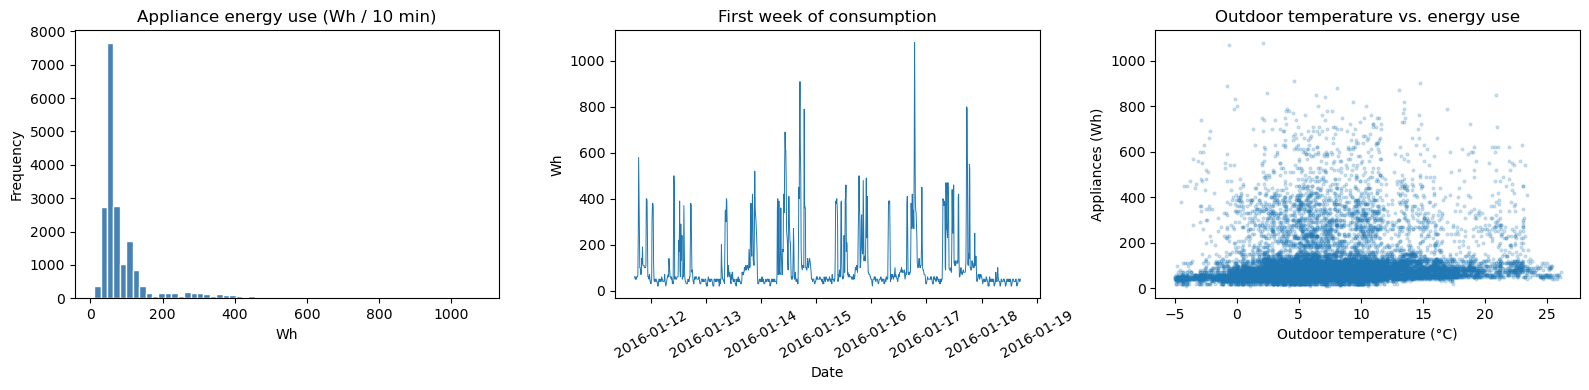


Target skewness: 3.39


In [19]:
# Quick look at the target distribution and a couple of representative features.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["Appliances"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Appliance energy use (Wh / 10 min)")
axes[0].set_xlabel("Wh")
axes[0].set_ylabel("Frequency")

axes[1].plot(df["date"][:24*6*7], df["Appliances"][:24*6*7], lw=0.7)
axes[1].set_title("First week of consumption")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Wh")
axes[1].tick_params(axis="x", rotation=30)

axes[2].scatter(df["T_out"], df["Appliances"], s=4, alpha=0.2)
axes[2].set_title("Outdoor temperature vs. energy use")
axes[2].set_xlabel("Outdoor temperature (°C)")
axes[2].set_ylabel("Appliances (Wh)")

plt.tight_layout()
plt.show()

print(f"\nTarget skewness: {df['Appliances'].skew():.2f}")

### Feature Engineering

Two things we need to do before training:

1. **Drop the random columns `rv1` and `rv2`.** The dataset authors added these
   as random noise specifically so researchers could benchmark whether their
   models accidentally fit to noise. We have no use for them here.
2. **Engineer time-of-day and day-of-week features** from the `date` column.
   Energy consumption is strongly cyclical — people cook in the evening, the
   house is empty during the workday — and a raw timestamp is useless to a
   feed-forward network. We'll encode the hour and day-of-week as sine/cosine
   pairs so the network sees that 23:00 and 00:00 are adjacent.


In [20]:
# Cyclical encoding for hour-of-day and day-of-week.
hours = df["date"].dt.hour + df["date"].dt.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hours / 24)
df["hour_cos"] = np.cos(2 * np.pi * hours / 24)

dow = df["date"].dt.dayofweek
df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

# Drop the noise columns and the raw date.
df = df.drop(columns=["rv1", "rv2", "date"])

target_col = "Appliances"
feature_cols = [c for c in df.columns if c != target_col]

print(f"Engineered features: {len(feature_cols)}")
print(feature_cols)

Engineered features: 29
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


### Train / Validation / Test Split + Scaling

We hold out a final test set the network never sees during training, and let
Keras carve a validation slice out of the training set so we can watch for
overfitting.


In [21]:
X = df[feature_cols].values
y = df[[target_col]].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}    y_test:  {y_test.shape}")

X_train: (15788, 29)   y_train: (15788, 1)
X_test:  (3947, 29)    y_test:  (3947, 1)


### Build a Deeper Network

For this problem we'll go beyond the single-hidden-layer model we used on California Housing. A few choices worth noting:

- **Three hidden layers (128 → 64 → 32).** The non-linearities here (occupancy patterns × weather × time-of-day) are interactive enough to justify depth.
- **Batch normalization** after each Dense layer. This keeps activations on a stable scale, lets us use a higher learning rate, and dramatically reduces the risk of vanishing or exploding gradients in deeper layers (a problem we'll discuss in the next section).
- **Dropout (0.2).** Light regularization — the dataset is small enough that the network can memorize noisy 10-minute windows otherwise.
- **He-normal initialization.** Designed by He et al. (2015) specifically for ReLU networks. Because ReLU zeros out roughly half of its inputs, the variance of activations would shrink as the signal flows through deep layers under classic initializers like Xavier/Glorot. He-normal compensates by sampling weights from $\mathcal{N}(0,\, 2 / n_{\text{in}})$ — the factor of 2 keeps activation variance roughly constant across layers, which in turn keeps the gradients well-scaled during backprop and gets training off to a much healthier start. (This is revisited in the next section.)


In [22]:
from tensorflow.keras import layers, models

def build_energy_model(input_dim: int) -> tf.keras.Model:
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.2),

        layers.Dense(64, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.2),

        layers.Dense(32, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Dense(1),  # Regression output
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mean_squared_error",
        metrics=["mae"],
    )
    return model

tf.keras.utils.set_random_seed(42)
model = build_energy_model(X_train.shape[1])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 448 (1.75 KB)

### Train with Diagnostics

We'll use **early stopping** to halt training once the validation loss stops improving, and **ReduceLROnPlateau** to drop the learning rate when we hit a plateau. Both are standard tools for any real-world training run.


In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5, verbose=0
    ),
]

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=120,
    batch_size=128,
    callbacks=callbacks,
    verbose=0,
)

print(f"Stopped after {len(history.history['loss'])} epochs.")

Stopped after 78 epochs.


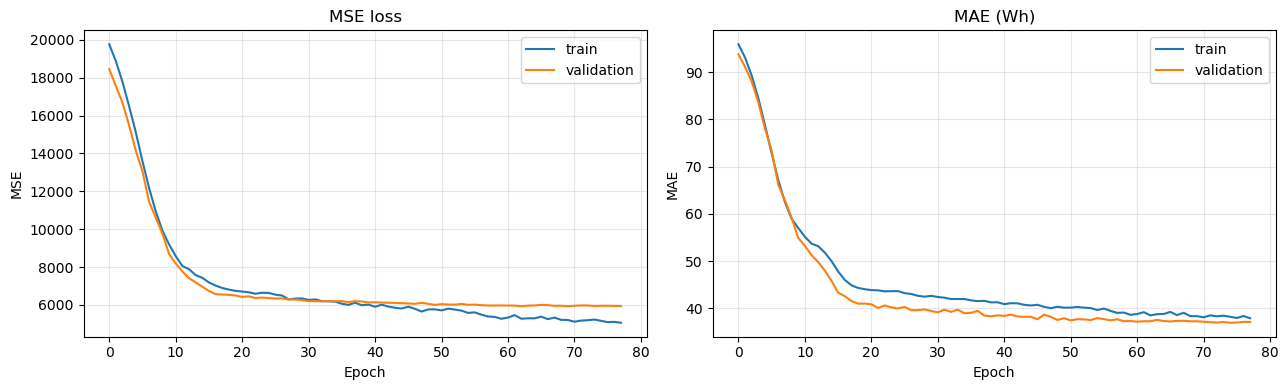

In [24]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("MSE loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="validation")
axes[1].set_title("MAE (Wh)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluate on the Hold-Out Test Set


In [27]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
y_pred = model.predict(X_test, verbose=0)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test MSE:   {mse:8.2f}")
print(f"Test RMSE:  {np.sqrt(mse):8.2f} Wh")
print(f"Test MAE:   {mae:8.2f} Wh")
print(f"Test R²:    {r2:8.3f}")
print(f"Naive baseline (predict mean): "
      f"R² = {r2_score(y_test, np.full_like(y_test, y_train.mean())):.3f}")

Test MSE:    5856.44
Test RMSE:     76.53 Wh
Test MAE:      36.72 Wh
Test R²:       0.415
Naive baseline (predict mean): R² = -0.000


### Inspect the Predictions

Two plots that are far more informative than a single test-set number:

1. **Predicted vs. actual** — points should cluster around the diagonal.
   Systematic curvature tells you the model is biased in part of the input
   space.
2. **Residuals vs. predicted** — residuals should look like noise. Any visible
   pattern (a funnel, a U-shape) signals heteroskedasticity or unmodeled
   structure.


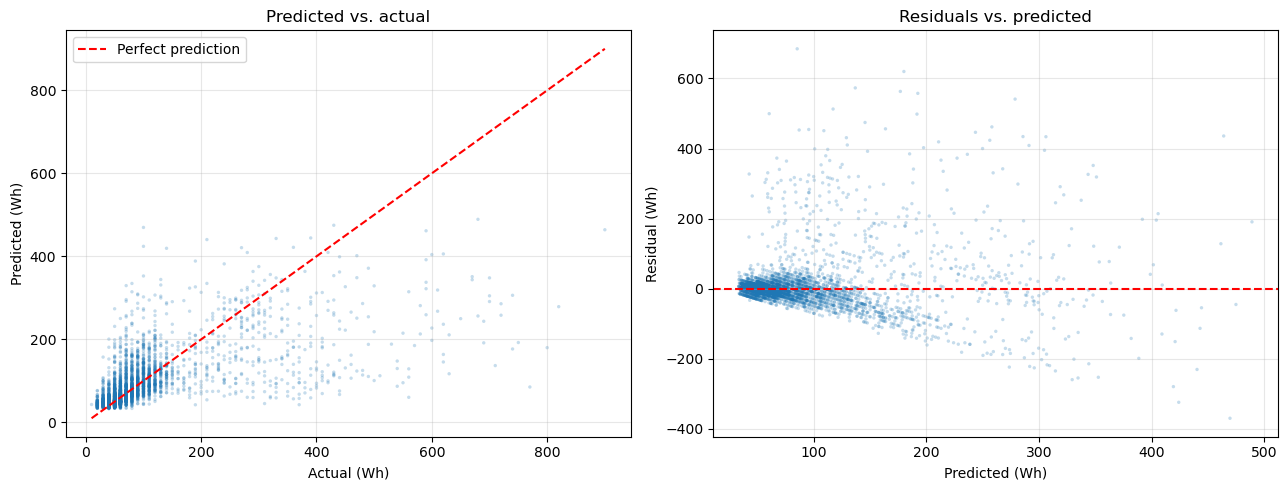

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs. actual
axes[0].scatter(y_test, y_pred, s=6, alpha=0.25, edgecolors="none")
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max()),
]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual (Wh)")
axes[0].set_ylabel("Predicted (Wh)")
axes[0].set_title("Predicted vs. actual")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals vs. predicted
residuals = (y_test - y_pred).flatten()
axes[1].scatter(y_pred, residuals, s=6, alpha=0.25, edgecolors="none")
axes[1].axhline(0, color="r", linestyle="--", lw=1.5)
axes[1].set_xlabel("Predicted (Wh)")
axes[1].set_ylabel("Residual (Wh)")
axes[1].set_title("Residuals vs. predicted")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Discussion

A few observations worth talking through:

- The model captures the **overall scale and rhythm** of energy consumption, but tends to *under-predict the largest spikes*. Those spikes correspond to cooking, laundry, and other discrete events that aren't really predictable from indoor temperature alone — without an explicit signal of human activity, no model will hit them perfectly.
- The **residual plot fans out** at higher predicted values. This is classic heteroskedasticity: variance grows with the mean. In practice, applying a `log1p` transform to the target (and `expm1` to predictions) often helps a lot here.
- We never had to write a single line of gradient code. Keras computed every partial derivative — for hundreds of thousands of parameters — by walking the computational graph backwards using exactly the chain rule we worked through by hand at the top of this notebook.

In the next section, we'll talk about what can go wrong with that backward pass — vanishing and exploding gradients — and the techniques (some of which we already quietly used, like batch normalization and He initialization) that keep training stable as networks get deeper.


## Vanishing And Exploding Gradients

As neural networks grow deeper (with more layers), training them can become unstable due to challenges such as vanishing gradients and exploding gradients. These challenges directly affect the performance of the network, causing either slow learning or unstable weight updates.

#### Vanishing Gradients

  During backpropagation, gradients are computed using the chain rule and propagated backward from the output layer to earlier layers. As the gradient flows backward, it is multiplied by small derivatives, especially if the network uses activation functions like **sigmoid** or **tanh**. This multiplication causes the gradients to become smaller and smaller as they move toward the input layer, effectively “vanishing.”

**Why is this a problem?**  
  - Weights in the earlier layers are updated very slowly or not at all, making it difficult for the network to learn meaningful features.  
  - This is particularly problematic for deep networks and recurrent neural networks (RNNs), where gradients may vanish before reaching the initial layers.

**Explaining the math:**  
  Suppose you have a network with several layers, and the activation function is **sigmoid**. The derivative of the sigmoid function is given by:  
  
  $$
  \sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))
  $$
  
  The maximum derivative of the sigmoid function is **0.25**. As the chain rule multiplies these small derivatives across layers, the gradients exponentially decrease, leading to very small updates.


#### Exploding Gradients

  The opposite of vanishing gradients occurs when the gradients grow exponentially large during backpropagation. This typically happens when the weights are initialized with large values or when the network is poorly tuned.

**Why is this a problem?**  
  - Large gradients result in **unstable weight updates**, causing the loss to diverge rather than converge.  
  - The model fails to learn, and the training process may halt due to numerical instability.

**Instability due to large gradients:**  
    Consider a network using **ReLU** activation where the gradient does not saturate like in sigmoid or tanh. If the gradients of the loss with respect to the weights accumulate too quickly (due to large activations or poorly initialized weights), the updates during gradient descent can become excessively large, resulting in erratic or diverging loss values.

## Correcting Vanishing And Exploding Gradients

#### Activation Function Choices

The choice of activation functions can significantly affect how gradients propagate through the network.  

- **Sigmoid and tanh** tend to cause vanishing gradients due to their saturating outputs.  
- **ReLU (Rectified Linear Unit)** and its variants (e.g., **Leaky ReLU**, **Parametric ReLU**) are preferred because they do not saturate for positive inputs, helping alleviate vanishing gradient problems.

**Example:**  
- Using **ReLU**:  
  $$
  f(x) = \max(0, x)
  $$
  
  The derivative is either **1** (for positive inputs) or **0** (for negative inputs). This ensures that the gradient does not decay as rapidly as in sigmoid or tanh.

#### Batch Normalization

Batch normalization normalizes the inputs to each layer, ensuring that the values lie within a stable range during training.  

- **How it helps:** By normalizing the inputs, batch normalization prevents the gradients from becoming too small or too large.  
- **Where it’s applied:** Typically applied before or after the activation function within each layer.
- **Effect of batch normalization:**  
    - Reduces internal covariate shift (where input distributions change during training). 
    - Helps accelerate training by making the gradients more stable.


In [29]:
from tensorflow.keras.layers import Dense, BatchNormalization, ReLU
from tensorflow.keras import Sequential

# Adding batch normalization in a neural network
model = Sequential([
    Dense(64, input_shape=(10,)),
    BatchNormalization(),  # Normalizes the inputs to this layer
    ReLU(),  # Activation function after normalization
    Dense(1)  # Output layer
])

/opt/anaconda3/envs/Teaching-TensorFlow/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Weight Initialization Techniques

Proper weight initialization can reduce both vanishing and exploding gradients by ensuring that the initial values of the weights do not lead to excessively large or small activations.

- **Xavier Initialization (Glorot Initialization):**  
  Used for layers with **sigmoid** or **tanh** activations.  
  $$
  W \sim \mathcal{U} \left( -\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}, \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}} \right)
  $$

- **He Initialization:**  
  Used for layers with **ReLU** activations.  
  $$
  W \sim \mathcal{N} \left( 0, \frac{2}{n_{\text{in}}} \right)
  $$


In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeNormal

model = Sequential([
    Dense(64, input_shape=(10,), kernel_initializer=HeNormal()),  # He initialization for ReLU
    tf.keras.layers.ReLU(),
    Dense(1)
])

#### Residual Connections (ResNets)

Residual networks (ResNets) address vanishing gradients in very deep networks by allowing the gradient to flow more directly through the network. Instead of passing the input through many layers sequentially, **residual connections** skip layers by adding the input to the output of a layer.

**How it helps:**  
- Residual connections help maintain a strong gradient signal even in deep networks by allowing the network to learn **identity mappings**.

**Residual connection formula:**  

Given the input $x$ and a function $F(x)$ representing the transformation of the layer:  

$$
\text{Output} = F(x) + x
$$


In [ ]:
import tensorflow as tf

class ResidualBlock(tf.keras.Model):
    def __init__(self, units):
        super(ResidualBlock, self).__init__()
        self.dense1 = tf.keras.layers.Dense(units, activation='relu')
        self.dense2 = tf.keras.layers.Dense(units)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return x + inputs  # Residual connection

## Practice: Build Your Own Neural Network

Now it's your turn to apply what you've learned. We'll work on the **Diabetes**
dataset (Efron et al., 2004), distributed with scikit-learn — a real medical
regression problem where the goal is to predict a patient's *disease
progression one year after baseline* from 10 routine clinical and blood-serum
measurements.

A few honest things to know up front:

- **The dataset is small (442 patients) and noisy.** Even a well-tuned linear
  baseline reaches only $R^2 \approx 0.5$, which is roughly the natural ceiling
  here. Don't expect $R^2 = 0.95$ no matter what architecture you try.
- **More capacity is not always better.** With this much data, a 2–3 hidden-layer
  MLP with light regularization will usually beat a much deeper network.
- This is exactly the kind of real-world dataset where the *engineering choices*
  (feature scaling, learning rate, early stopping) matter as much as the
  architecture.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Diabetes dataset (Efron et al., 2004) — shipped with scikit-learn.
#
# Real medical regression problem. For 442 diabetes patients we have 10
# baseline measurements; the target is a quantitative measure of disease
# progression one year later. Features:
#
#   age, sex, bmi (body mass index), bp (average blood pressure),
#   s1-s6  (six blood-serum measurements: cholesterol fractions,
#           triglycerides, blood glucose, etc.)
#
# Scikit-learn ships this with each feature centered and scaled so the
# sum of squares per column equals 1 — a bit unusual. We'll apply a standard
# normal rescaling for nicer neural-network training.
diabetes = load_diabetes()
X = diabetes.data                         # shape: (442, 10)
y = diabetes.target.reshape(-1, 1)        # disease-progression score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_names = diabetes.feature_names
df = pd.DataFrame(X_scaled, columns=feature_names)
df["target"] = y

print(f"Dataset shape: {X_scaled.shape}")
print(f"Target range:  [{y.min():.0f}, {y.max():.0f}]")
print(f"Target mean:   {y.mean():.1f}    std: {y.std():.1f}")
print("\nFirst few rows:")
df.head()

### Your Task

Using `X_scaled` and `y` from above, complete the following steps:

1. **Split the data** into training and test sets
2. **Build a neural network** using TensorFlow/Keras
3. **Compile the model** with an appropriate optimizer and loss function
4. **Train the model** on the training data
5. **Evaluate the model** on the test set

### Things to Consider

- What loss function is appropriate for regression?
- How many hidden layers do you need? How many neurons per layer?
  (Hint: with only 442 patients, less is more.)
- Which activation functions work well for regression problems?
- What learning rate should you use?
- How many epochs should you train for — and should you use early stopping?
- Would batch normalization or dropout help on a dataset this small?
- A reasonable test-set $R^2$ here is in the **0.4–0.55** range. Anything
  dramatically higher is suspicious — most likely a data leakage bug, or
  you're looking at training set numbers by accident.


#### Step 1: Split the Data

In [ ]:
# Split the data into training and test sets



#### Step 2: Build the Neural Network

In [ ]:
# Build your neural network model



#### Step 3: Compile the Model

In [ ]:
# Compile your model with an optimizer and loss function



#### Step 4: Train the Model

In [ ]:
# Train your model



#### Step 5: Evaluate the Model

In [ ]:
# Evaluate your model on the test set



#### Visualize Your Results

Run the cell below to see how your predictions compare to the actual values. A perfect model would have all points along the diagonal line.

In [ ]:
import matplotlib.pyplot as plt

# Make predictions on test set
y_pred = model.predict(X_test)

# Create scatter plot of predicted vs actual
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='none')

# Add diagonal line (perfect predictions)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Predicted vs Actual Values', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  R² Score: {r2:.4f}")